# 🩸 Extract Blood Labels from CholecSeg8k

This notebook:
1. Parses CholecSeg8k directory structure
2. Extracts Class 7 (Blood) from 13-class watershed masks
3. Shows multiple sample images of original frames + blood masks
4. Creates organized blood-only dataset for training

---

In [1]:
# Cell 1: Setup and Imports
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
import json
from collections import defaultdict

print("✅ Imports complete!")

✅ Imports complete!


In [2]:
# Cell 2: Define Paths
BASE_DIR = Path("cholecseg8k_raw")  # Your downloaded dataset
OUTPUT_DIR = Path("cholecseg8k_blood")  # Organized blood dataset

# Create output structure
OUTPUT_DIR.mkdir(exist_ok=True)
(OUTPUT_DIR / "images").mkdir(exist_ok=True)
(OUTPUT_DIR / "masks").mkdir(exist_ok=True)
(OUTPUT_DIR / "samples").mkdir(exist_ok=True)

print(f"📁 Input directory: {BASE_DIR}")
print(f"📁 Output directory: {OUTPUT_DIR}")
print(f"✅ Directories created!")

📁 Input directory: cholecseg8k_raw
📁 Output directory: cholecseg8k_blood
✅ Directories created!


In [3]:
# Cell 3: Understand CholecSeg8k Structure
print("🔍 Analyzing CholecSeg8k structure...\n")

# Find all video directories
video_dirs = sorted([d for d in BASE_DIR.iterdir() if d.is_dir() and d.name.startswith('video')])

print(f"📊 Found {len(video_dirs)} video directories:")
for vdir in video_dirs:
    print(f"  - {vdir.name}")

# Analyze one video to understand structure
sample_video = video_dirs[0]
print(f"\n🔬 Analyzing sample video: {sample_video.name}")

# Find subdirectories
subdirs = sorted([d for d in sample_video.iterdir() if d.is_dir()])
print(f"  Subdirectories: {len(subdirs)}")
print(f"  Example: {subdirs[0].name}")

# Find files in first subdir
sample_subdir = subdirs[0]
files = sorted([f for f in sample_subdir.iterdir() if f.is_file()])

print(f"\n📄 Files in {sample_subdir.name}:")
for f in files[:10]:  # Show first 10
    size_kb = f.stat().st_size / 1024
    print(f"  - {f.name} ({size_kb:.1f} KB)")

# Identify file types
print(f"\n🎨 File types identified:")
endo_files = [f for f in files if '_endo.png' in f.name and 'mask' not in f.name]
watershed_files = [f for f in files if 'watershed_mask.png' in f.name]
print(f"  - Original images (*_endo.png): {len(endo_files)}")
print(f"  - Watershed masks (*_watershed_mask.png): {len(watershed_files)}")

if endo_files:
    print(f"\n✅ Sample frame: {endo_files[0].name}")
if watershed_files:
    print(f"✅ Sample mask: {watershed_files[0].name}")

🔍 Analyzing CholecSeg8k structure...

📊 Found 17 video directories:
  - video01
  - video09
  - video12
  - video17
  - video18
  - video20
  - video24
  - video25
  - video26
  - video27
  - video28
  - video35
  - video37
  - video43
  - video48
  - video52
  - video55

🔬 Analyzing sample video: video01
  Subdirectories: 16
  Example: video01_00080

📄 Files in video01_00080:
  - frame_100_endo.png (420.6 KB)
  - frame_100_endo_color_mask.png (5.6 KB)
  - frame_100_endo_mask.png (12.9 KB)
  - frame_100_endo_watershed_mask.png (5.5 KB)
  - frame_101_endo.png (431.3 KB)
  - frame_101_endo_color_mask.png (5.7 KB)
  - frame_101_endo_mask.png (11.9 KB)
  - frame_101_endo_watershed_mask.png (5.6 KB)
  - frame_102_endo.png (407.4 KB)
  - frame_102_endo_color_mask.png (5.4 KB)

🎨 File types identified:
  - Original images (*_endo.png): 80
  - Watershed masks (*_watershed_mask.png): 80

✅ Sample frame: frame_100_endo.png
✅ Sample mask: frame_100_endo_watershed_mask.png


In [4]:
# Cell 4: CholecSeg8k Class Definitions
print("📋 CholecSeg8k has 13 classes:\n")

CLASS_NAMES = {
    0: "Black Background",
    1: "Abdominal Wall",
    2: "Liver",
    3: "Gastrointestinal Tract",
    4: "Fat",
    5: "Grasper",
    6: "Connective Tissue",
    7: "Blood",  # ← THIS IS WHAT WE WANT!
    8: "Cystic Duct",
    9: "L-hook Electrocautery",
    10: "Gallbladder",
    11: "Hepatic Vein",
    12: "Liver Ligament"
}

CLASS_COLORS = {
    0: "#505050",  # Gray
    1: "#111111",
    2: "#212121",
    3: "#131313",
    4: "#121212",
    5: "#313131",
    6: "#232323",
    7: "#242424",  # Blood (very dark gray in watershed)
    8: "#252525",
    9: "#323232",
    10: "#222222",
    11: "#333333",
    12: "#050505"
}

for class_id, class_name in CLASS_NAMES.items():
    marker = "🩸" if class_id == 7 else "  "
    print(f"{marker} Class {class_id:2d}: {class_name}")

print(f"\n🎯 Target: Extract Class 7 (Blood) from all frames")

📋 CholecSeg8k has 13 classes:

   Class  0: Black Background
   Class  1: Abdominal Wall
   Class  2: Liver
   Class  3: Gastrointestinal Tract
   Class  4: Fat
   Class  5: Grasper
   Class  6: Connective Tissue
🩸 Class  7: Blood
   Class  8: Cystic Duct
   Class  9: L-hook Electrocautery
   Class 10: Gallbladder
   Class 11: Hepatic Vein
   Class 12: Liver Ligament

🎯 Target: Extract Class 7 (Blood) from all frames


In [5]:
# Cell 5: Collect All Frame-Mask Pairs
print("🔍 Collecting all frame-mask pairs...\n")

frame_mask_pairs = []

for video_dir in tqdm(video_dirs, desc="Scanning videos"):
    # Find all subdirectories
    subdirs = sorted([d for d in video_dir.iterdir() if d.is_dir()])
    
    for subdir in subdirs:
        # Find all endo frames
        endo_files = sorted([f for f in subdir.glob('*_endo.png') if 'mask' not in f.name])
        
        for endo_file in endo_files:
            # Construct watershed mask filename
            base_name = endo_file.stem  # e.g., "frame_100_endo"
            watershed_file = endo_file.parent / f"{base_name}_watershed_mask.png"
            
            if watershed_file.exists():
                frame_mask_pairs.append({
                    'video': video_dir.name,
                    'subdir': subdir.name,
                    'frame': endo_file,
                    'mask': watershed_file
                })

print(f"\n✅ Found {len(frame_mask_pairs):,} frame-mask pairs!")

# Show breakdown by video
video_counts = defaultdict(int)
for pair in frame_mask_pairs:
    video_counts[pair['video']] += 1

print(f"\n📊 Frames per video:")
for video, count in sorted(video_counts.items()):
    print(f"  {video}: {count:,} frames")

🔍 Collecting all frame-mask pairs...



Scanning videos: 100%|██████████████████████████████████████████████████████████████████████████████| 17/17 [00:00<00:00, 137.39it/s]


✅ Found 8,080 frame-mask pairs!

📊 Frames per video:
  video01: 1,280 frames
  video09: 240 frames
  video12: 640 frames
  video17: 320 frames
  video18: 160 frames
  video20: 160 frames
  video24: 960 frames
  video25: 320 frames
  video26: 320 frames
  video27: 400 frames
  video28: 560 frames
  video35: 240 frames
  video37: 480 frames
  video43: 720 frames
  video48: 240 frames
  video52: 800 frames
  video55: 240 frames


Classes in this frame: [ 12  21  22  23  24  31  32  50 255]


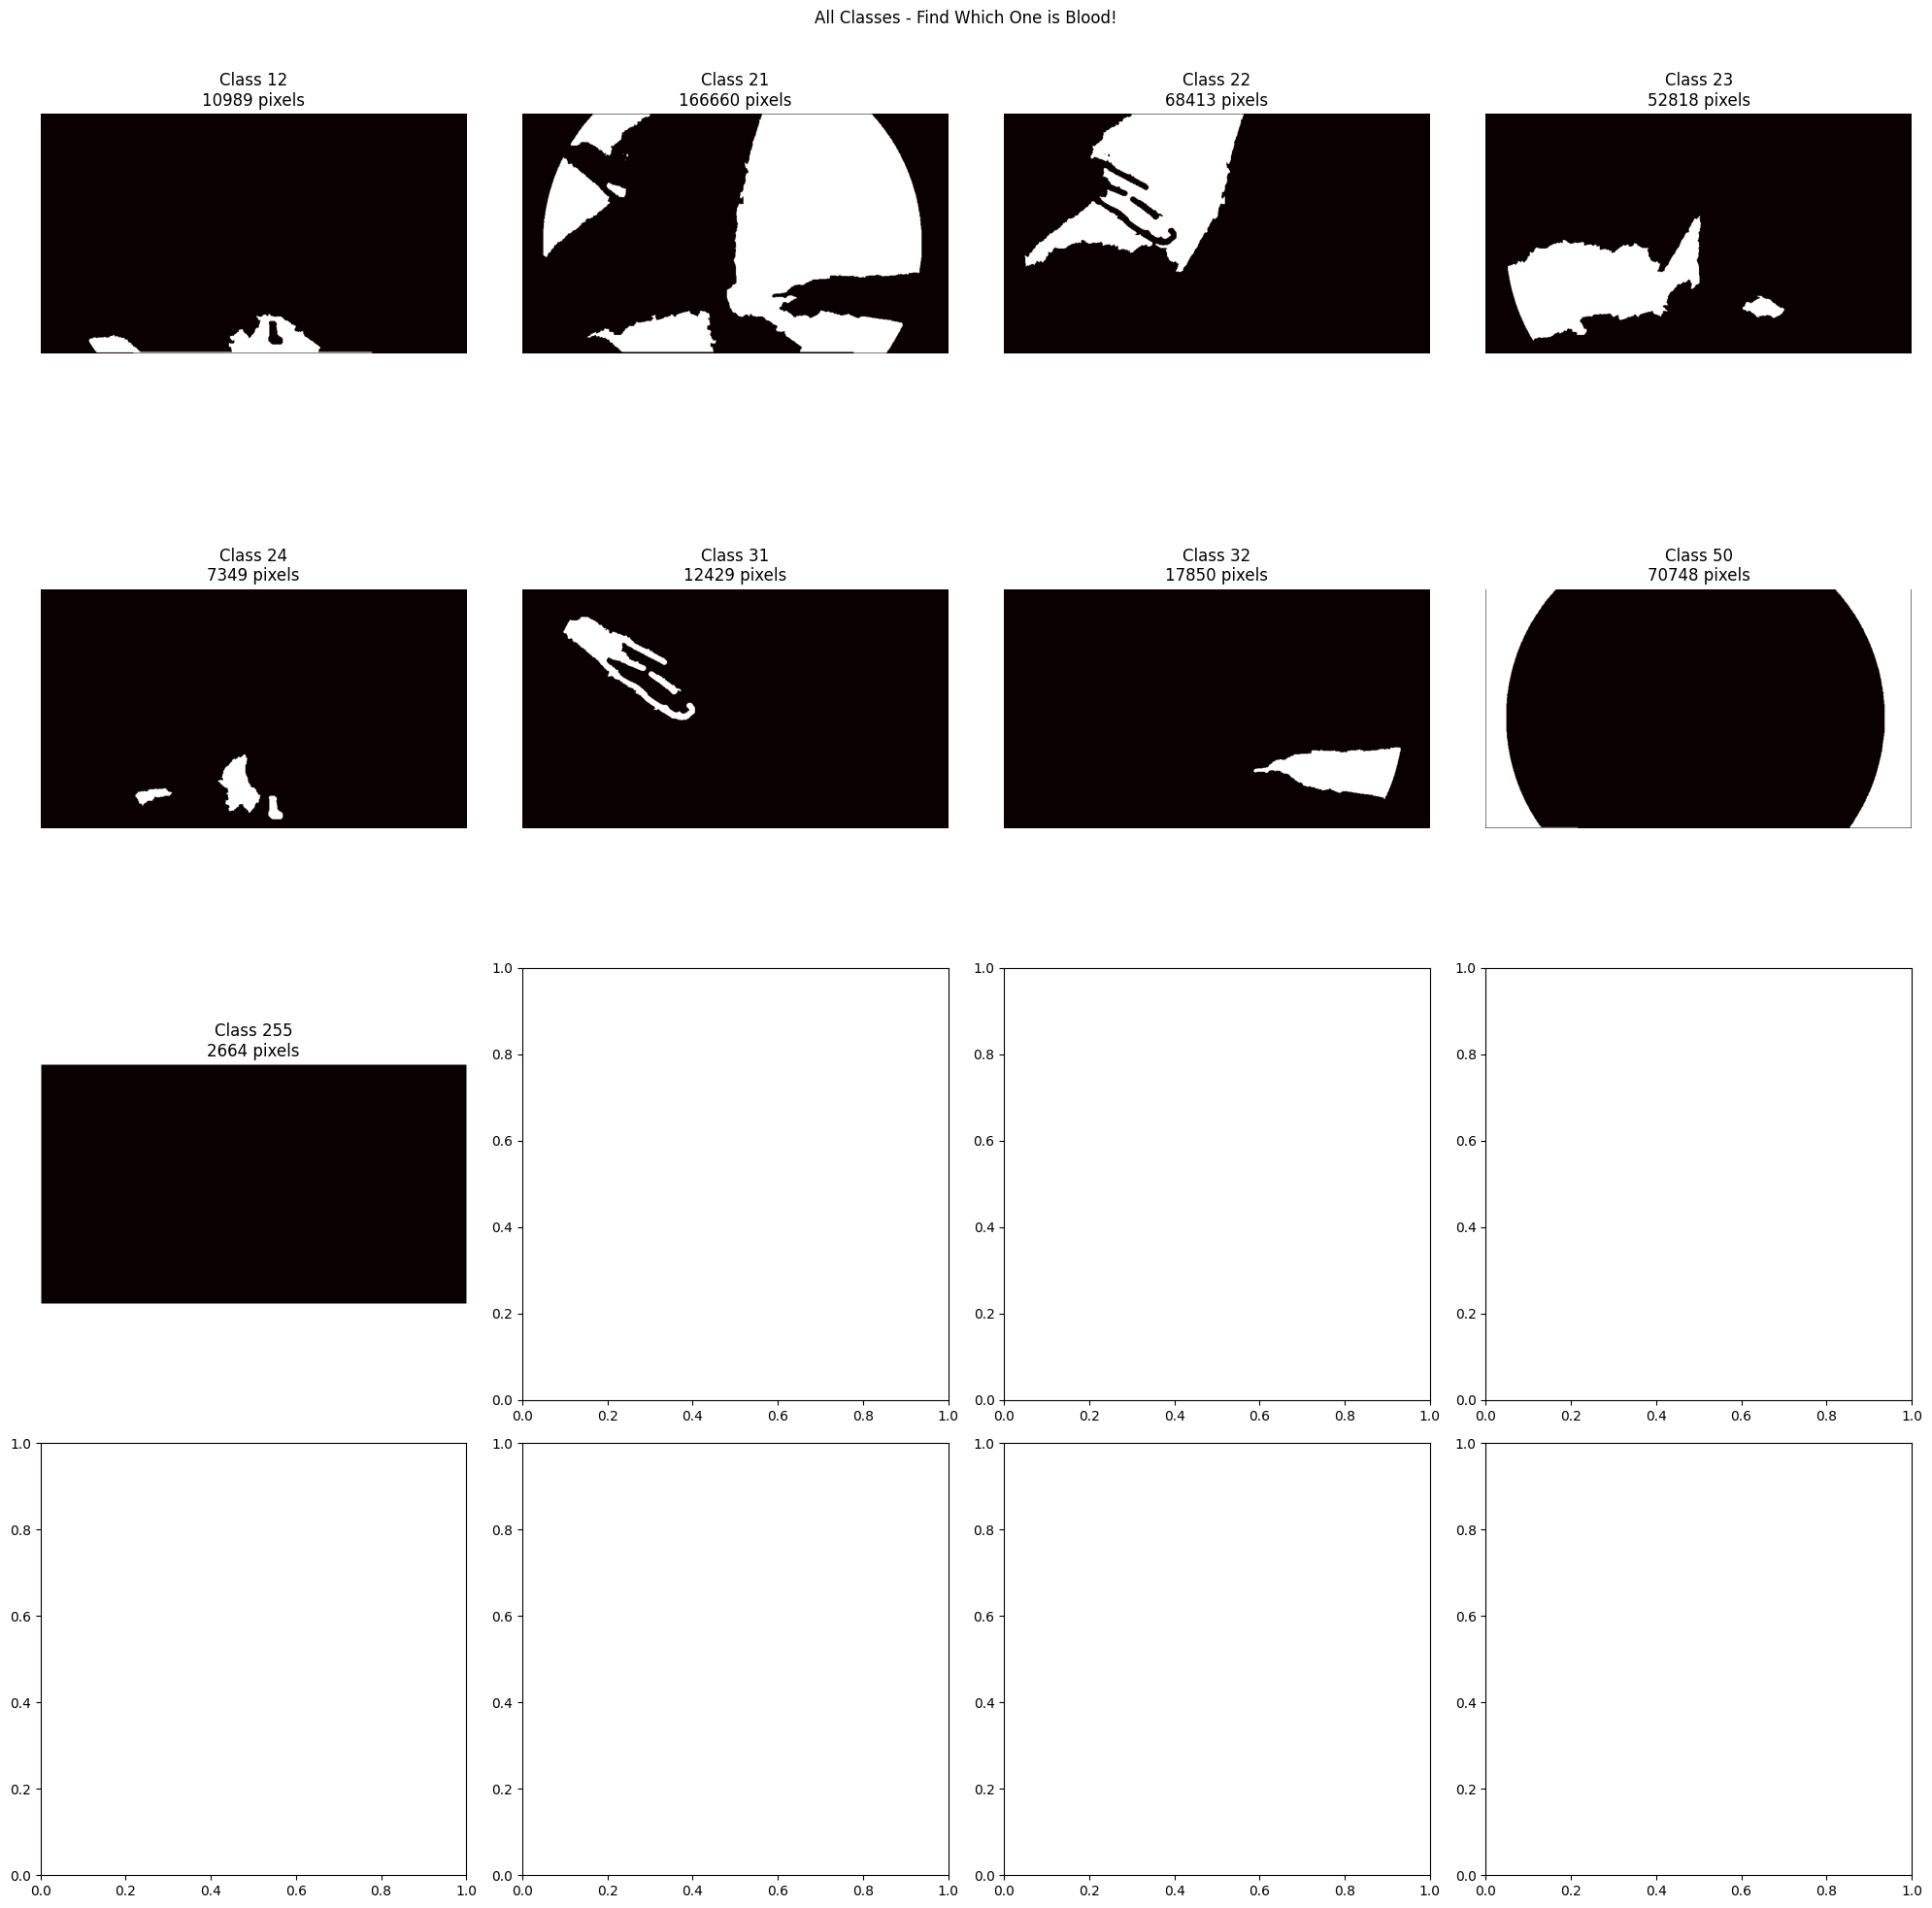

In [30]:
# Pick one frame
sample_pair = frame_mask_pairs[1278]

frame = cv2.imread(str(sample_pair['frame']))
frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
mask = cv2.imread(str(sample_pair['mask']), cv2.IMREAD_GRAYSCALE)

# Show which classes are present
unique_classes = np.unique(mask)
print(f"Classes in this frame: {unique_classes}")

# Visualize EACH class separately
fig, axes = plt.subplots(4, 4, figsize=(20, 20))
axes = axes.flatten()

for i, class_id in enumerate(unique_classes):
    if i >= 16:
        break
    
    # Extract this class
    class_mask = (mask == class_id).astype(np.uint8) * 255
    
    # Show it
    axes[i].imshow(class_mask, cmap='hot')
    axes[i].set_title(f'Class {class_id}\n{np.sum(mask == class_id)} pixels')
    axes[i].axis('off')

plt.suptitle('All Classes - Find Which One is Blood!')
plt.tight_layout()
plt.show()

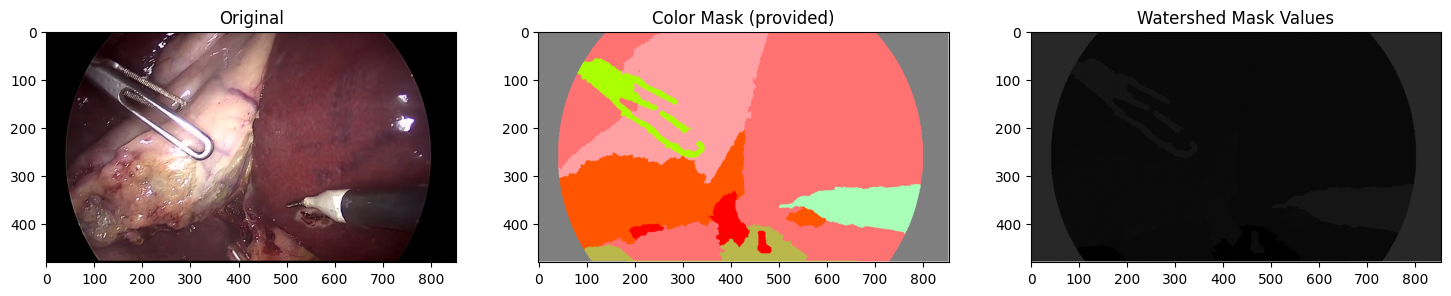

In [31]:
# Load the color mask that comes with dataset
color_mask = cv2.imread(str(sample_pair['frame'].parent / f"{sample_pair['frame'].stem}_color_mask.png"))
color_mask_rgb = cv2.cvtColor(color_mask, cv2.COLOR_BGR2RGB)

# Show side by side
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
axes[0].imshow(frame_rgb)
axes[0].set_title('Original')
axes[1].imshow(color_mask_rgb)
axes[1].set_title('Color Mask (provided)')
axes[2].imshow(mask, cmap='gray')
axes[2].set_title('Watershed Mask Values')
plt.show()

# What color is blood in the color mask?
# Then find which grayscale value corresponds to that color

In [14]:
# 1. Check a few frames for blood visually
sample_pairs = random.sample(frame_mask_pairs, 5)

for pair in sample_pairs:
    frame = cv2.imread(str(pair['frame']))
    mask = cv2.imread(str(pair['mask']), cv2.IMREAD_GRAYSCALE)
    
    print(f"\n{pair['frame'].name}")
    print(f"Classes present: {np.unique(mask)}")
    print(f"Most common class: {np.argmax(np.bincount(mask.flatten()))}")


frame_16659_endo.png
Classes present: [ 11  12  13  21  22  23  24  25  31  50 255]
Most common class: 21

frame_545_endo.png
Classes present: [ 11  12  21  22  31  50 255]
Most common class: 11

frame_261_endo.png
Classes present: [ 11  12  21  31  50 255]
Most common class: 11

frame_201_endo.png
Classes present: [ 11  12  21  22  31  50 255]
Most common class: 11

frame_555_endo.png
Classes present: [ 11  12  21  22  31  50 255]
Most common class: 11


In [33]:
# Cell 6: Analyze Class Distribution (Sample)
print("🔬 Analyzing class distribution in sample frames...\n")

# Sample 100 random frames for analysis
import random
sample_pairs = random.sample(frame_mask_pairs, min(100, len(frame_mask_pairs)))

class_pixel_counts = defaultdict(int)
frames_with_class = defaultdict(int)

for pair in tqdm(sample_pairs, desc="Analyzing samples"):
    # Load watershed mask
    mask = cv2.imread(str(pair['mask']), cv2.IMREAD_GRAYSCALE)
    
    # Count pixels for each class
    unique_classes, counts = np.unique(mask, return_counts=True)
    
    for class_id, count in zip(unique_classes, counts):
        class_pixel_counts[class_id] += count
        if count > 0:
            frames_with_class[class_id] += 1

print(f"📊 Class distribution in {len(sample_pairs)} sample frames:\n")
total_pixels = sum(class_pixel_counts.values())

for class_id in sorted(class_pixel_counts.keys()):
    count = class_pixel_counts[class_id]
    percentage = 100 * count / total_pixels
    frames = frames_with_class[class_id]
    class_name = CLASS_NAMES.get(class_id, f"Unknown-{class_id}")
    
    marker = "🩸" if class_id == 24 else "  "
    print(f"{marker} Class {class_id:2d} ({class_name:25s}): {percentage:5.2f}% of pixels, present in {frames:3d}/{len(sample_pairs)} frames")

# Calculate frames with blood
blood_frames = frames_with_class.get(24, 0)
blood_percentage = 100 * blood_frames / len(sample_pairs)
print(f"\n🩸 Blood is present in {blood_frames}/{len(sample_pairs)} frames ({blood_percentage:.1f}%)")

🔬 Analyzing class distribution in sample frames...



Analyzing samples: 100%|██████████████████████████████████████████████████████████████████████████| 100/100 [00:00<00:00, 227.55it/s]

📊 Class distribution in 100 sample frames:

   Class  0 (Black Background         ):  0.00% of pixels, present in   1/100 frames
   Class  5 (Grasper                  ):  0.75% of pixels, present in   5/100 frames
   Class 11 (Hepatic Vein             ): 21.74% of pixels, present in  90/100 frames
   Class 12 (Liver Ligament           ): 15.09% of pixels, present in  94/100 frames
   Class 13 (Unknown-13               ):  1.58% of pixels, present in  52/100 frames
   Class 21 (Unknown-21               ): 21.37% of pixels, present in 100/100 frames
   Class 22 (Unknown-22               ):  6.75% of pixels, present in  88/100 frames
   Class 23 (Unknown-23               ):  2.15% of pixels, present in  22/100 frames
🩸 Class 24 (Unknown-24               ):  0.28% of pixels, present in   8/100 frames
   Class 25 (Unknown-25               ):  0.05% of pixels, present in   4/100 frames
   Class 31 (Unknown-31               ):  2.46% of pixels, present in  82/100 frames
   Class 32 (Unknown-3

🎨 Visualizing sample frames with all 13 classes...

Found 6 frames with blood. Visualizing...



/tmp/ipykernel_3101591/2212160994.py:59: UserWarning: Glyph 129656 (\N{DROP OF BLOOD}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3101591/2212160994.py:82: UserWarning: Glyph 129656 (\N{DROP OF BLOOD}) missing from font(s) DejaVu Sans.
  fig.savefig(output_path, dpi=150, bbox_inches='tight')
/raid/bsmse6/miniconda3/envs/surgical/lib/python3.14/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 129656 (\N{DROP OF BLOOD}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


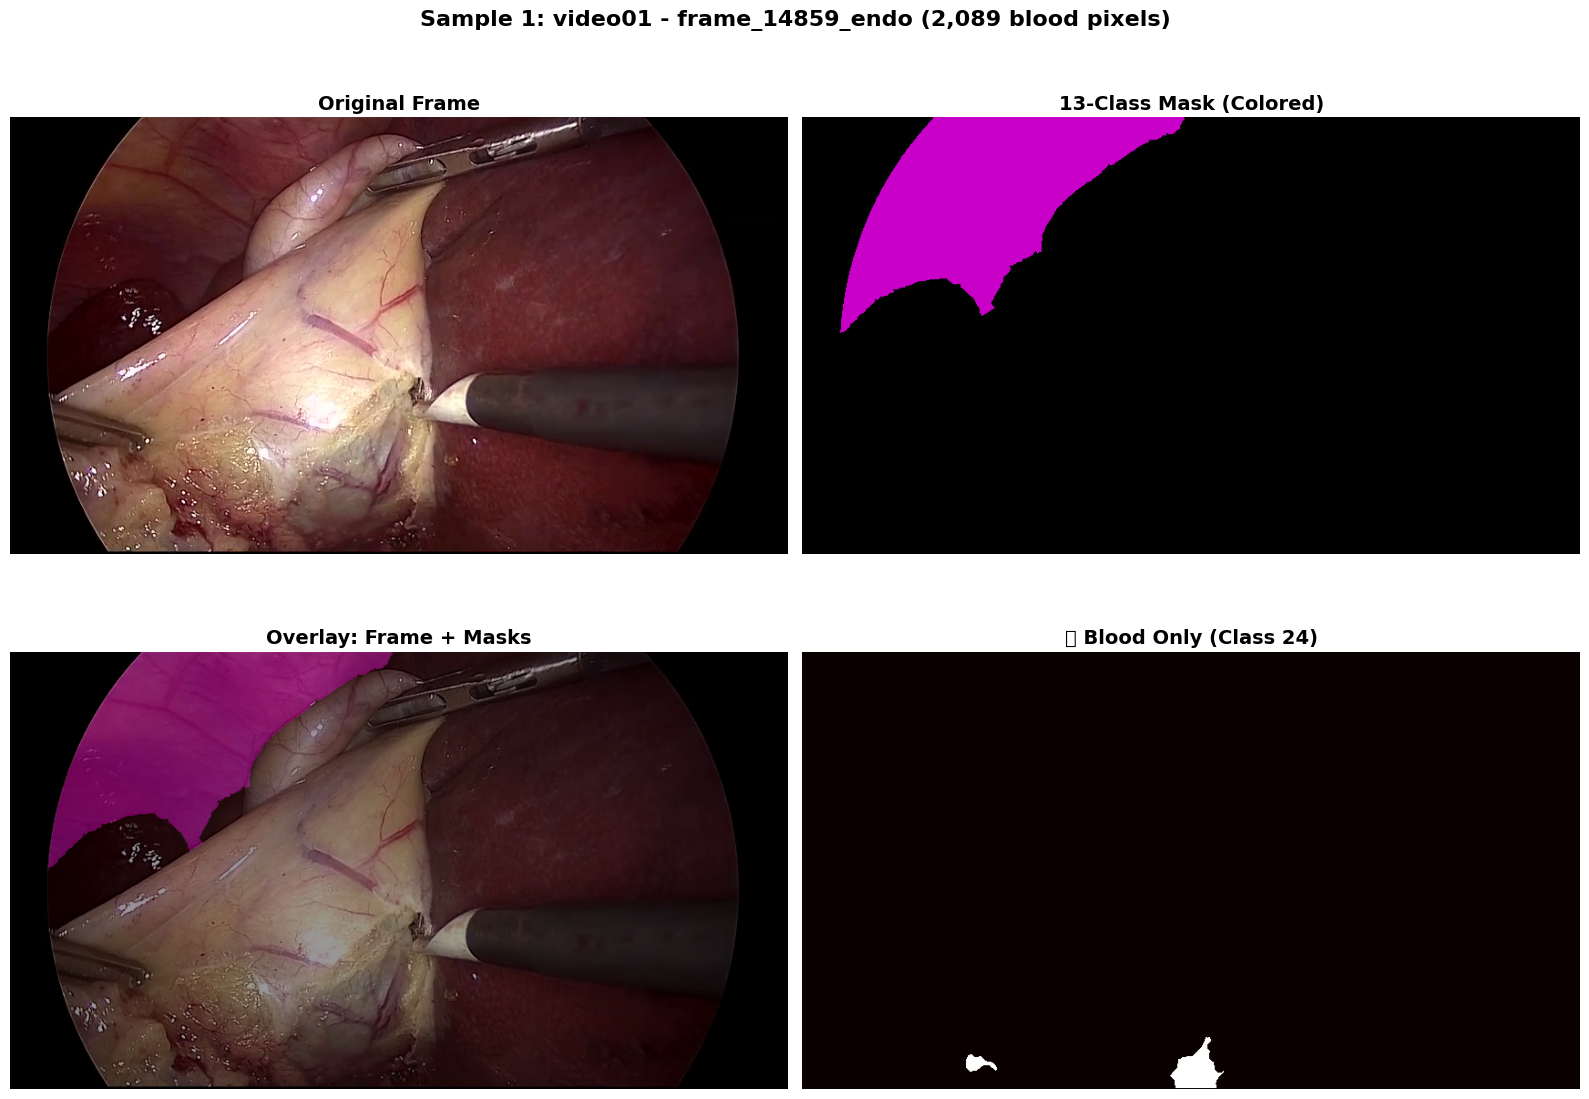

✅ Saved: cholecseg8k_blood/samples/sample_01_analysis.png



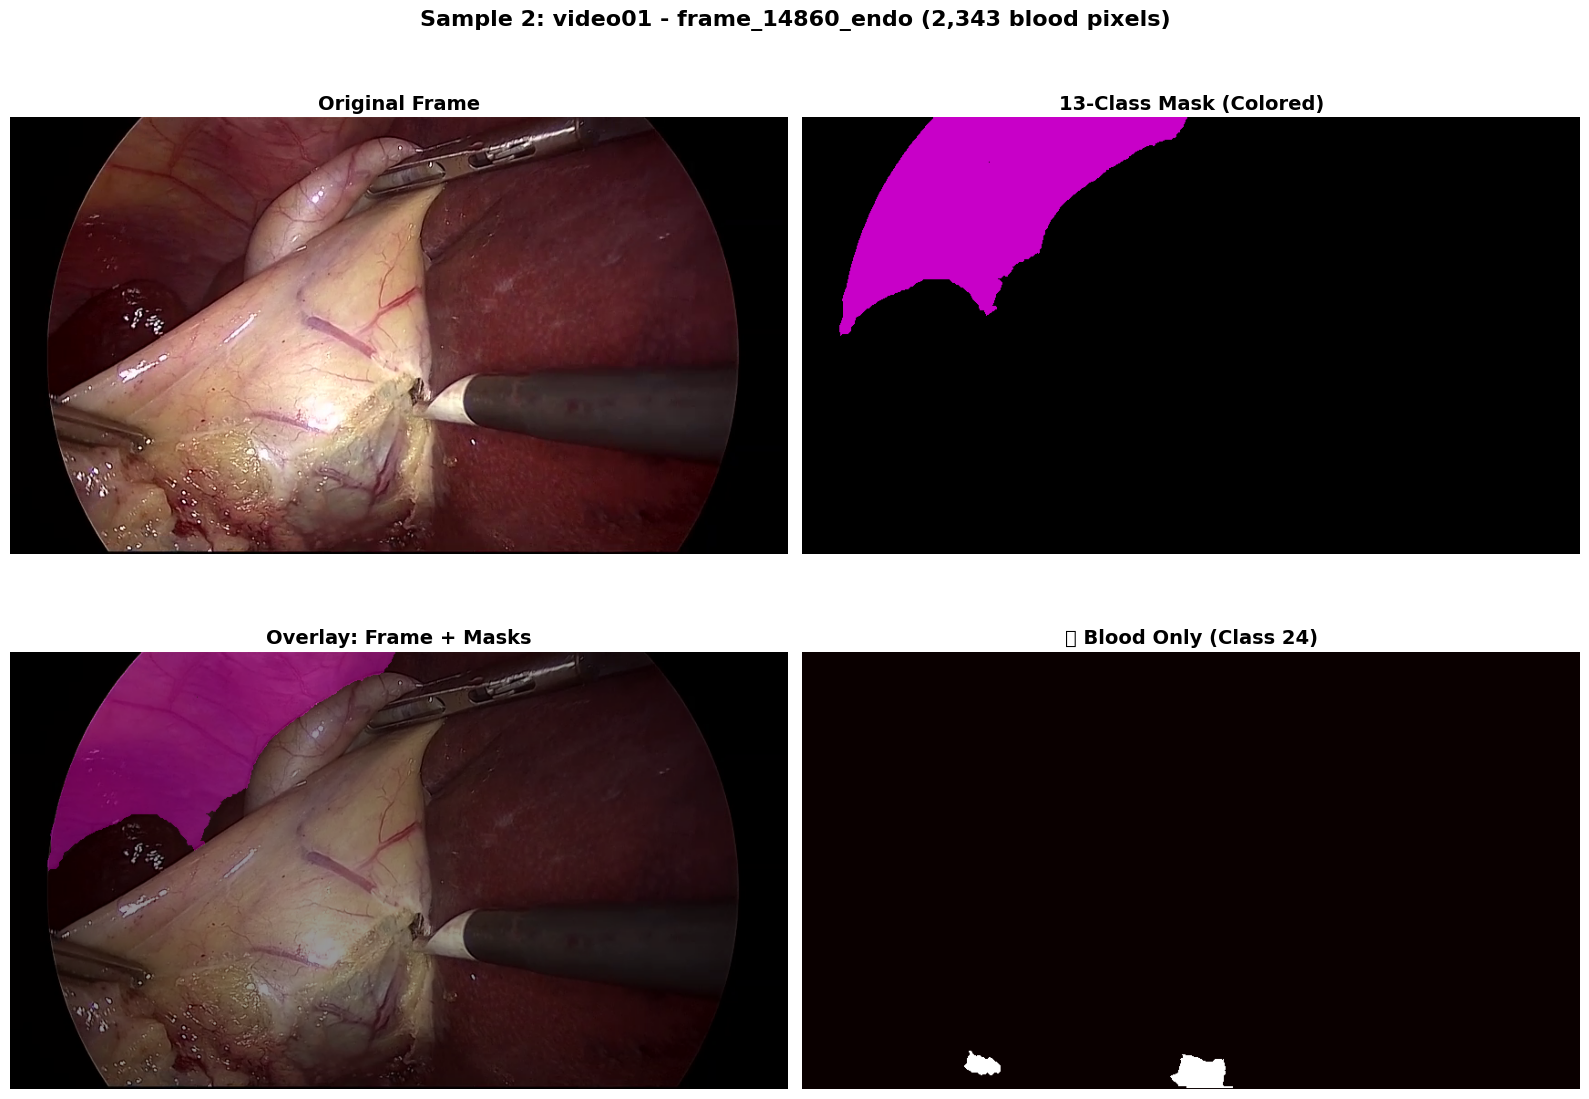

✅ Saved: cholecseg8k_blood/samples/sample_02_analysis.png



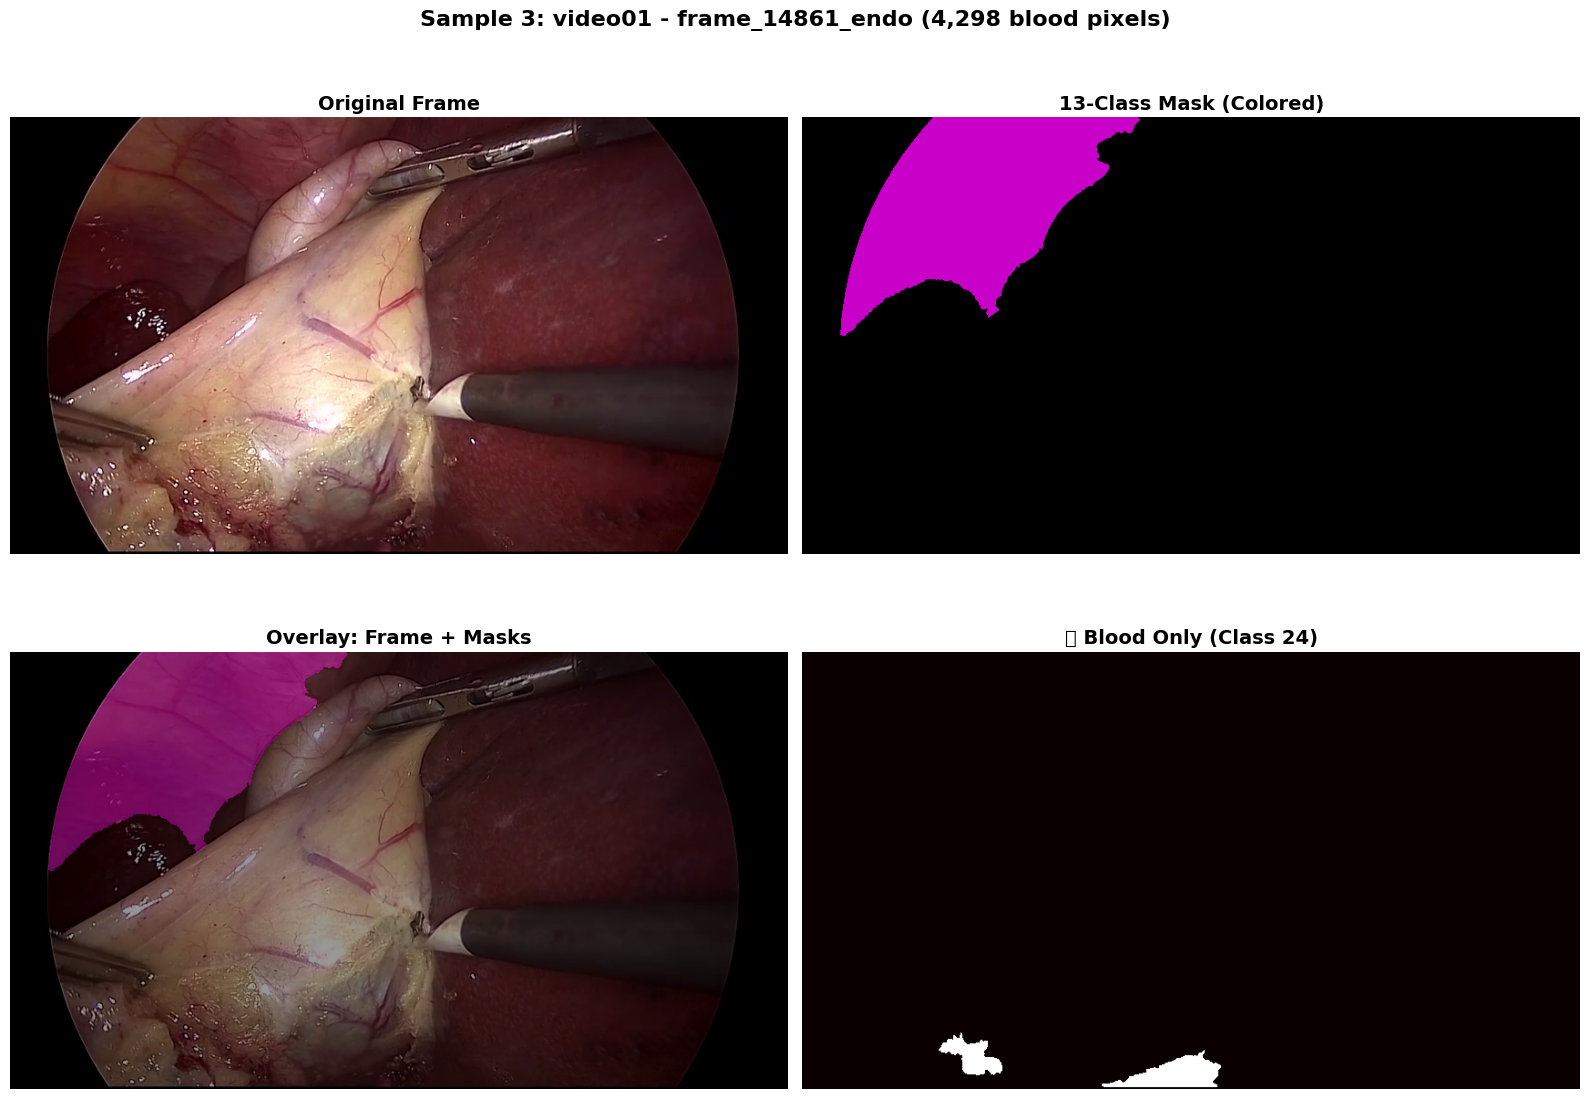

✅ Saved: cholecseg8k_blood/samples/sample_03_analysis.png

✅ Visualizations complete!


In [34]:
# Cell 7: Visualize Sample Frames with All Classes
print("🎨 Visualizing sample frames with all 13 classes...\n")

def visualize_classes(frame_path, mask_path, title=""):
    """Visualize frame with original, mask overlay, and individual classes"""
    
    # Load images
    frame = cv2.imread(str(frame_path))
    frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
    mask = cv2.imread(str(mask_path), cv2.IMREAD_GRAYSCALE)
    
    # Create colored mask
    colored_mask = np.zeros((*mask.shape, 3), dtype=np.uint8)
    colors = [
        [80, 80, 80],    # 0: Background (gray)
        [255, 0, 0],     # 1: Abdominal Wall (red)
        [0, 255, 0],     # 2: Liver (green)
        [0, 0, 255],     # 3: GI Tract (blue)
        [255, 255, 0],   # 4: Fat (yellow)
        [255, 0, 255],   # 5: Grasper (magenta)
        [0, 255, 255],   # 6: Connective Tissue (cyan)
        [255, 100, 100], # 7: BLOOD (light red)
        [100, 255, 100], # 8: Cystic Duct (light green)
        [100, 100, 255], # 9: L-hook (light blue)
        [200, 200, 0],   # 10: Gallbladder (dark yellow)
        [200, 0, 200],   # 11: Hepatic Vein (dark magenta)
        [0, 200, 200],   # 12: Liver Ligament (dark cyan)
    ]
    
    for class_id, color in enumerate(colors):
        colored_mask[mask == class_id] = color
    
    # Create overlay
    overlay = cv2.addWeighted(frame_rgb, 0.6, colored_mask, 0.4, 0)
    
    # Extract blood mask (Class 24)
    blood_mask = (mask == 24).astype(np.uint8) * 255
    
    # Plot
    fig, axes = plt.subplots(2, 2, figsize=(16, 12))
    
    axes[0, 0].imshow(frame_rgb)
    axes[0, 0].set_title('Original Frame', fontsize=14, fontweight='bold')
    axes[0, 0].axis('off')
    
    axes[0, 1].imshow(colored_mask)
    axes[0, 1].set_title('13-Class Mask (Colored)', fontsize=14, fontweight='bold')
    axes[0, 1].axis('off')
    
    axes[1, 0].imshow(overlay)
    axes[1, 0].set_title('Overlay: Frame + Masks', fontsize=14, fontweight='bold')
    axes[1, 0].axis('off')
    
    axes[1, 1].imshow(blood_mask, cmap='hot')
    axes[1, 1].set_title('🩸 Blood Only (Class 24)', fontsize=14, fontweight='bold')
    axes[1, 1].axis('off')
    
    plt.suptitle(title, fontsize=16, fontweight='bold')
    plt.tight_layout()
    
    return fig, blood_mask

# Find frames with blood
frames_with_blood = []
for pair in frame_mask_pairs[:500]:  # Check first 500
    mask = cv2.imread(str(pair['mask']), cv2.IMREAD_GRAYSCALE)
    if np.any(mask == 24):  # Has blood
        blood_pixels = np.sum(mask == 24)
        frames_with_blood.append((pair, blood_pixels))
        if len(frames_with_blood) >= 6:  # Get 6 samples
            break

print(f"Found {len(frames_with_blood)} frames with blood. Visualizing...\n")

# Visualize 3 samples
for i, (pair, blood_pixels) in enumerate(frames_with_blood[:3]):
    title = f"Sample {i+1}: {pair['video']} - {pair['frame'].stem} ({blood_pixels:,} blood pixels)"
    fig, _ = visualize_classes(pair['frame'], pair['mask'], title)
    
    # Save
    output_path = OUTPUT_DIR / "samples" / f"sample_{i+1:02d}_analysis.png"
    fig.savefig(output_path, dpi=150, bbox_inches='tight')
    plt.show()
    plt.close()
    
    print(f"✅ Saved: {output_path}\n")

print(f"✅ Visualizations complete!")

In [36]:
# Cell 8: Extract Blood Labels from ALL Frames
print("🩸 Extracting blood labels from all frames...\n")
print(f"Processing {len(frame_mask_pairs):,} frame-mask pairs...\n")

blood_stats = {
    'total_frames': len(frame_mask_pairs),
    'frames_with_blood': 0,
    'frames_without_blood': 0,
    'total_blood_pixels': 0,
    'min_blood_pixels': float('inf'),
    'max_blood_pixels': 0,
    'video_stats': defaultdict(lambda: {'with_blood': 0, 'without_blood': 0})
}

processed_count = 0

for pair in tqdm(frame_mask_pairs, desc="Extracting blood masks"):
    # Load watershed mask
    mask = cv2.imread(str(pair['mask']), cv2.IMREAD_GRAYSCALE)
    
    # Extract blood (Class 7)
    blood_mask = (mask == 24).astype(np.uint8) * 255
    
    # Count blood pixels
    blood_pixels = np.sum(blood_mask == 255)
    
    # Update stats
    if blood_pixels > 0:
        blood_stats['frames_with_blood'] += 1
        blood_stats['total_blood_pixels'] += blood_pixels
        blood_stats['min_blood_pixels'] = min(blood_stats['min_blood_pixels'], blood_pixels)
        blood_stats['max_blood_pixels'] = max(blood_stats['max_blood_pixels'], blood_pixels)
        blood_stats['video_stats'][pair['video']]['with_blood'] += 1
    else:
        blood_stats['frames_without_blood'] += 1
        blood_stats['video_stats'][pair['video']]['without_blood'] += 1
    
    # Create output filename
    # Format: video01_frame_100.jpg and video01_frame_100_mask.png
    frame_name = pair['frame'].stem.replace('_endo', '')  # Remove _endo suffix
    output_name = f"{pair['video']}_{frame_name}"
    
    # Save original frame
    output_frame_path = OUTPUT_DIR / "images" / f"{output_name}.jpg"
    frame = cv2.imread(str(pair['frame']))
    cv2.imwrite(str(output_frame_path), frame)
    
    # Save blood mask
    output_mask_path = OUTPUT_DIR / "masks" / f"{output_name}_mask.png"
    cv2.imwrite(str(output_mask_path), blood_mask)
    
    processed_count += 1

# Fix min value if no blood found
if blood_stats['frames_with_blood'] == 0:
    blood_stats['min_blood_pixels'] = 0

print(f"\n✅ Extraction complete!")
print(f"\n📊 Blood Statistics:")
print(f"  Total frames processed: {blood_stats['total_frames']:,}")
print(f"  Frames WITH blood: {blood_stats['frames_with_blood']:,} ({100*blood_stats['frames_with_blood']/blood_stats['total_frames']:.1f}%)")
print(f"  Frames WITHOUT blood: {blood_stats['frames_without_blood']:,} ({100*blood_stats['frames_without_blood']/blood_stats['total_frames']:.1f}%)")
print(f"\n🩸 Blood Pixel Statistics:")
print(f"  Total blood pixels: {blood_stats['total_blood_pixels']:,}")
print(f"  Min blood pixels (in frames with blood): {blood_stats['min_blood_pixels']:,}")
print(f"  Max blood pixels: {blood_stats['max_blood_pixels']:,}")
if blood_stats['frames_with_blood'] > 0:
    avg_blood = blood_stats['total_blood_pixels'] / blood_stats['frames_with_blood']
    print(f"  Average blood pixels (in frames with blood): {avg_blood:,.0f}")

print(f"\n📹 Blood presence by video:")
for video in sorted(blood_stats['video_stats'].keys()):
    vstats = blood_stats['video_stats'][video]
    total = vstats['with_blood'] + vstats['without_blood']
    pct = 100 * vstats['with_blood'] / total if total > 0 else 0
    print(f"  {video}: {vstats['with_blood']:4d}/{total:4d} frames with blood ({pct:5.1f}%)")

🩸 Extracting blood labels from all frames...

Processing 8,080 frame-mask pairs...



Extracting blood masks: 100%|████████████████████████████████████████████████████████████████████| 8080/8080 [01:35<00:00, 84.95it/s]


✅ Extraction complete!

📊 Blood Statistics:
  Total frames processed: 8,080
  Frames WITH blood: 692 (8.6%)
  Frames WITHOUT blood: 7,388 (91.4%)

🩸 Blood Pixel Statistics:
  Total blood pixels: 13,991,063
  Min blood pixels (in frames with blood): 62
  Max blood pixels: 46,389
  Average blood pixels (in frames with blood): 20,218

📹 Blood presence by video:
  video01:  692/1280 frames with blood ( 54.1%)
  video09:    0/ 240 frames with blood (  0.0%)
  video12:    0/ 640 frames with blood (  0.0%)
  video17:    0/ 320 frames with blood (  0.0%)
  video18:    0/ 160 frames with blood (  0.0%)
  video20:    0/ 160 frames with blood (  0.0%)
  video24:    0/ 960 frames with blood (  0.0%)
  video25:    0/ 320 frames with blood (  0.0%)
  video26:    0/ 320 frames with blood (  0.0%)
  video27:    0/ 400 frames with blood (  0.0%)
  video28:    0/ 560 frames with blood (  0.0%)
  video35:    0/ 240 frames with blood (  0.0%)
  video37:    0/ 480 frames with blood (  0.0%)
  video43:    

In [ ]:
# Cell 9: Save Metadata
print("💾 Saving metadata...\n")

metadata = {
    'dataset': 'CholecSeg8k Blood Extraction',
    'source': 'CholecSeg8k (Kaggle)',
    'extraction_date': str(pd.Timestamp.now()),
    'statistics': blood_stats,
    'class_info': {
        'target_class': 24,
        'target_class_name': 'Blood',
        'total_classes': 13
    },
    'output_structure': {
        'images': str(OUTPUT_DIR / 'images'),
        'masks': str(OUTPUT_DIR / 'masks'),
        'samples': str(OUTPUT_DIR / 'samples')
    }
}

# Save as JSON
metadata_path = OUTPUT_DIR / 'metadata.json'
with open(metadata_path, 'w') as f:
    json.dump(metadata, f, indent=2, default=str)

print(f"✅ Metadata saved: {metadata_path}")

# Save as text report
report_path = OUTPUT_DIR / 'extraction_report.txt'
with open(report_path, 'w') as f:
    f.write("="*70 + "\n")
    f.write("CHOLECSEG8K BLOOD EXTRACTION REPORT\n")
    f.write("="*70 + "\n\n")
    f.write(f"Total Frames Processed: {blood_stats['total_frames']:,}\n")
    f.write(f"Frames with Blood: {blood_stats['frames_with_blood']:,}\n")
    f.write(f"Frames without Blood: {blood_stats['frames_without_blood']:,}\n")
    f.write(f"\nBlood Coverage: {100*blood_stats['frames_with_blood']/blood_stats['total_frames']:.2f}%\n")
    f.write("\n" + "="*70 + "\n")

print(f"✅ Report saved: {report_path}")

print(f"\n🎉 Blood extraction complete!")
print(f"\n📁 Output structure:")
print(f"  {OUTPUT_DIR}/")
print(f"  ├── images/          ({blood_stats['total_frames']:,} frames)")
print(f"  ├── masks/           ({blood_stats['total_frames']:,} blood masks)")
print(f"  ├── samples/         (visualization samples)")
print(f"  ├── metadata.json    (statistics and info)")
print(f"  └── extraction_report.txt")

In [ ]:
# Cell 10: Create Train/Val/Test Split
print("📊 Creating train/validation/test split...\n")

# Get all image files
all_images = sorted(list((OUTPUT_DIR / "images").glob("*.jpg")))
print(f"Total images: {len(all_images):,}")

# Split: 70% train, 15% val, 15% test
np.random.seed(42)
indices = np.random.permutation(len(all_images))

n_train = int(0.70 * len(all_images))
n_val = int(0.15 * len(all_images))

train_indices = indices[:n_train]
val_indices = indices[n_train:n_train+n_val]
test_indices = indices[n_train+n_val:]

print(f"\nSplit sizes:")
print(f"  Train: {len(train_indices):,} frames ({100*len(train_indices)/len(all_images):.1f}%)")
print(f"  Val:   {len(val_indices):,} frames ({100*len(val_indices)/len(all_images):.1f}%)")
print(f"  Test:  {len(test_indices):,} frames ({100*len(test_indices)/len(all_images):.1f}%)")

# Save split
split_info = {
    'train': [all_images[i].name for i in train_indices],
    'val': [all_images[i].name for i in val_indices],
    'test': [all_images[i].name for i in test_indices]
}

split_path = OUTPUT_DIR / 'train_val_test_split.json'
with open(split_path, 'w') as f:
    json.dump(split_info, f, indent=2)

print(f"\n✅ Split saved: {split_path}")

# Also save as text files
for split_name, split_indices in [('train', train_indices), ('val', val_indices), ('test', test_indices)]:
    split_txt = OUTPUT_DIR / f'{split_name}_files.txt'
    with open(split_txt, 'w') as f:
        for idx in split_indices:
            f.write(all_images[idx].name + '\n')
    print(f"✅ Saved: {split_txt}")

print(f"\n🎉 Dataset preparation complete!")
print(f"\n📋 Next step: Train UNet++ on this blood-labeled dataset!")

---
## ✅ Summary

This notebook successfully:
1. ✅ Parsed CholecSeg8k structure (17 videos, 8,080 frames)
2. ✅ Extracted Class 7 (Blood) from 13-class watershed masks
3. ✅ Created binary blood segmentation dataset
4. ✅ Generated sample visualizations
5. ✅ Created train/val/test split (70/15/15)

**Output:**
- `cholecseg8k_blood/images/` - Original frames
- `cholecseg8k_blood/masks/` - Binary blood masks
- `cholecseg8k_blood/samples/` - Sample visualizations
- `cholecseg8k_blood/metadata.json` - Dataset statistics
- `cholecseg8k_blood/train_val_test_split.json` - Data split

**Next:** Train UNet++ in Notebook 03! 🚀
---